In [3]:
# !pip install kagglehub==1.0.0

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import os
from pathlib import Path

path = None

# Caminhos possiveis para correr localmente, em Colab runtime, ou no Google Drive montado.
dataset_candidates = [
    Path("./aca-butterflies"),
    Path("/content/ACA/aca-butterflies"),
    Path("/content/drive/MyDrive/content/ACA/aca-butterflies"),
    Path("/content/drive/MyDrive/ACA/aca-butterflies"),
]

# Se estivermos no Colab, monta o Google Drive para aceder a /content/drive/MyDrive/...
try:
    import google.colab
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    pass

for candidate_path in dataset_candidates:
    has_train_csv = (candidate_path / "train.csv").exists()
    has_train_dir = (candidate_path / "train").is_dir()
    has_test_dir = (candidate_path / "test").is_dir()

    if has_train_csv and has_train_dir and has_test_dir:
        path = str(candidate_path)
        break

if path is None:
    raise FileNotFoundError(
        "Dataset nao encontrado. Confirma se a pasta aca-butterflies esta em "
        "MyDrive/content/ACA/aca-butterflies ou ajusta dataset_candidates."
    )

print("Path to dataset files:", path)
print("train.csv:", os.path.exists(os.path.join(path, "train.csv")))
print("train folder:", os.path.exists(os.path.join(path, "train")))
print("test folder:", os.path.exists(os.path.join(path, "test")))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Path to dataset files: /content/drive/MyDrive/content/ACA/aca-butterflies
train.csv: True
train folder: True
test folder: True


In [6]:
# if path is None:
#     # do not forget to enter the Kaggle competition through the link in the project statement (section 4)
#     path = kagglehub.competition_download('aca-tp-2')
#     print("Path to dataset files:", path)

In [7]:
import os
import random
from collections import Counter, defaultdict
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.utils.data as data
import torchvision.transforms as transforms
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import ConcatDataset, DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import copy

In [8]:
SEED = 42
BATCH_SIZE = 32
IMAGE_SIZE = 64
EPOCHS = 50 # 50
PATIENCE = 5
best_val_loss = float('inf')
patience_counter = 0
latent_size = 100
EPOCHS_VAE = 50 # 50
PATIENCE_VAE = 10
EPOCHS_GAN = 50 # 50
PATIENCE_GAN = 10

# Parâmetros da geração e filtragem sintética.
BETA_KL = 0.001
VAE_LATENT_NOISE_STD = 0.15
NUM_IMAGES_TO_GENERATE = 10000
BATCH_Z = 100
CONFIDENCE_THRESHOLD = 0.85
MAX_SYNTHETIC_PER_CLASS = 50


def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_global_seed(SEED)
print(f'Seed global definida: {SEED}')
print(f'BETA_KL={BETA_KL} | VAE_LATENT_NOISE_STD={VAE_LATENT_NOISE_STD} | MAX_SYNTHETIC_PER_CLASS={MAX_SYNTHETIC_PER_CLASS}')

Seed global definida: 42
BETA_KL=0.001 | VAE_LATENT_NOISE_STD=0.15 | MAX_SYNTHETIC_PER_CLASS=50


In [9]:
class ButterflyDataset(data.Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.img_labels = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

        self.classes = sorted(self.img_labels['label'].unique())
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_name = self.img_labels.iloc[idx]['filename']
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        label_name = self.img_labels.iloc[idx]['label']
        label_idx = self.class_to_idx[label_name]
        label = torch.tensor(label_idx, dtype=torch.long)

        if self.transform:
            image = self.transform(image)

        return image, label

## First, we read the dataset, preprocess the images and encapsulate them into dataloader form.

In [10]:
# load the data
img_dir = os.path.join(path, 'train')
df = pd.read_csv(os.path.join(path, 'train.csv'))

# preprocessing
data_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

# encapsulate data into dataloader form
dataset = ButterflyDataset(df=df, img_dir=img_dir, transform=data_transform)
dataloader = data.DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED)
)

In [11]:
print(f"Number of samples: {len(dataset)}")
print(f"Number of classes: {len(dataset.classes)}")

Number of samples: 5199
Number of classes: 75


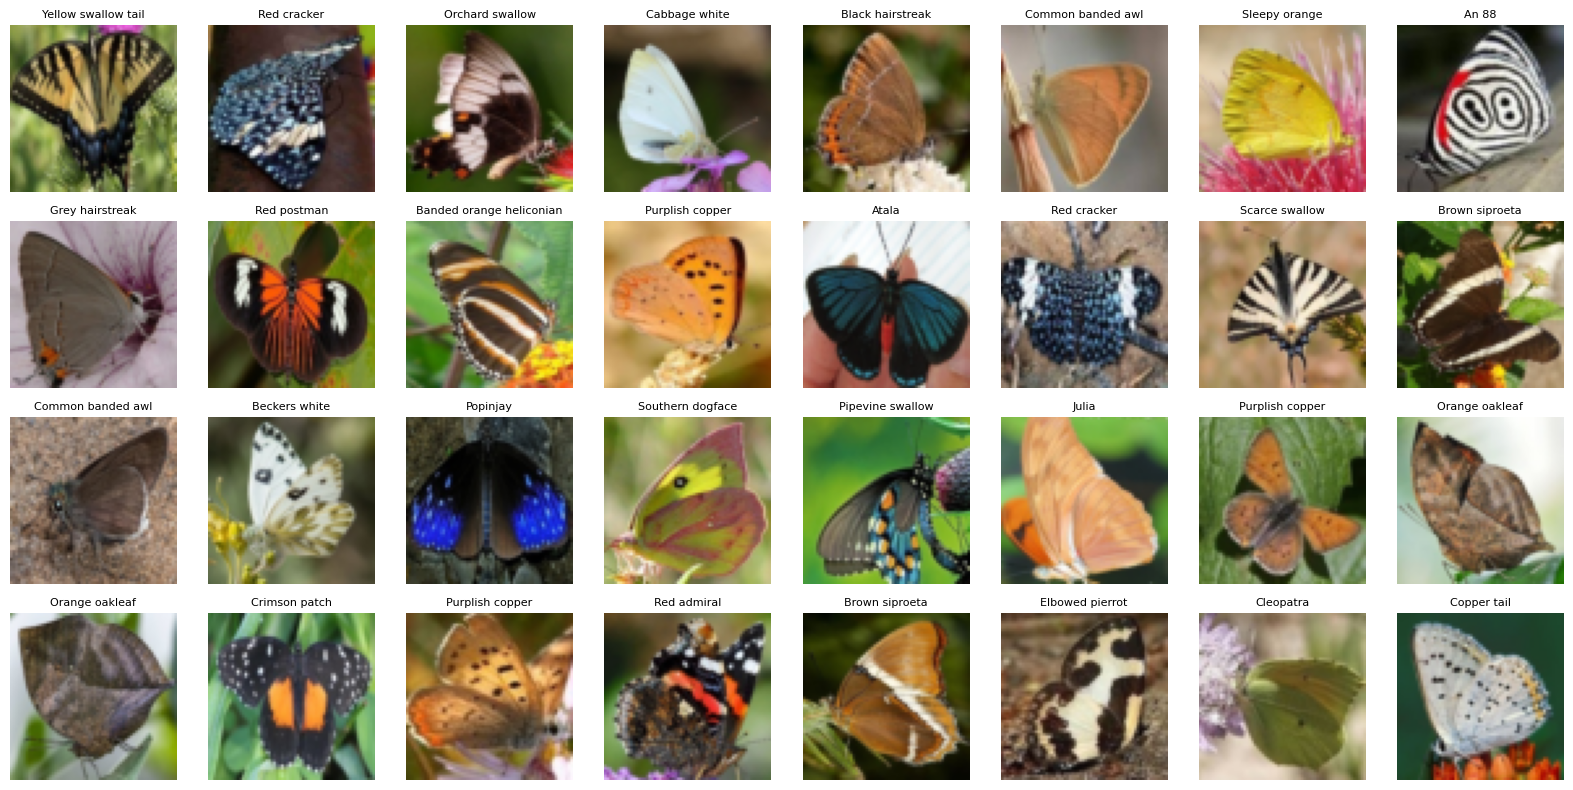

In [12]:
# Get a batch of images from the dataloader
images, labels = next(iter(dataloader))

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()

for i, img in enumerate(images):
    img = img.permute(1, 2, 0).numpy()
    label_idx = labels[i].item()
    label_name = dataset.classes[label_idx]
    axes[i].imshow(img)
    axes[i].set_title(label_name.capitalize(), fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Classifier

In [13]:
import torch.nn as nn

class BaselineCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2)
            )

        self.features = nn.Sequential(
            conv_block(3, 64),
            conv_block(64, 128),
            conv_block(128, 256),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            *[layer for size in [256, 512, 1024]
            for layer in (nn.Linear(size, size*2), nn.ReLU(inplace=True), nn.Dropout(p=0.5))],
            nn.Linear(2048, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

In [14]:
n_classes = len(dataset.classes)
model = BaselineCNN(num_classes=n_classes)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

N.1 - Divisão do Dataset e Criação dos DataLoaders

In [15]:
# Divisão: 70% Treino, 30% Temporário
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=SEED, stratify=df['label'])

# Divisão do Temporário: 50% Validação (15% do total), 50% Teste (15% do total)
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['label'])

# Criar as instâncias do Dataset (assumindo que 'data_transform' e 'img_dir' já estão definidos)
train_dataset = ButterflyDataset(df=train_df, img_dir=img_dir, transform=data_transform)
val_dataset = ButterflyDataset(df=val_df, img_dir=img_dir, transform=data_transform)
test_dataset = ButterflyDataset(df=test_df, img_dir=img_dir, transform=data_transform)

# Criar os DataLoaders
train_loader = data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED)
)
val_loader = data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Amostras de Treino: {len(train_dataset)}")
print(f"Amostras de Validação: {len(val_dataset)}")
print(f"Amostras de Teste: {len(test_dataset)}")

Amostras de Treino: 3639
Amostras de Validação: 780
Amostras de Teste: 780


N.2 - Ciclo de Treino com Avaliação e Early Stopping

In [16]:
# Configuração do dispositivo (GPU se disponível, senão CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Guardar os melhores pesos do modelo
best_model_weights = copy.deepcopy(model.state_dict())

for epoch in range(EPOCHS):
    # --- FASE DE TREINO ---
    model.train()
    train_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

    train_loss /= len(train_loader.dataset)

    # --- FASE DE VALIDAÇÃO ---
    model.eval()
    val_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss /= len(val_loader.dataset)

    # Calcular Métricas (Accuracy e F1-Score)
    val_accuracy = accuracy_score(all_labels, all_preds)
    val_f1 = f1_score(all_labels, all_preds, average='weighted')

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.4f} | Val F1: {val_f1:.4f}")

    # --- EARLY STOPPING ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_weights = copy.deepcopy(model.state_dict()) # Guarda o melhor modelo
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping ativado na época {epoch+1}! A loss de validação não melhorou durante {PATIENCE} épocas.")
            break

Epoch 01/50 | Train Loss: 4.1649 | Val Loss: 4.2020 | Val Acc: 0.0436 | Val F1: 0.0101
Epoch 02/50 | Train Loss: 3.7578 | Val Loss: 3.6069 | Val Acc: 0.0821 | Val F1: 0.0345
Epoch 03/50 | Train Loss: 3.5919 | Val Loss: 3.5365 | Val Acc: 0.0782 | Val F1: 0.0376
Epoch 04/50 | Train Loss: 3.4805 | Val Loss: 3.2557 | Val Acc: 0.1269 | Val F1: 0.0664
Epoch 05/50 | Train Loss: 3.3301 | Val Loss: 3.1340 | Val Acc: 0.1564 | Val F1: 0.0907
Epoch 06/50 | Train Loss: 3.2214 | Val Loss: 3.0924 | Val Acc: 0.1603 | Val F1: 0.0954
Epoch 07/50 | Train Loss: 3.0998 | Val Loss: 2.9051 | Val Acc: 0.1949 | Val F1: 0.1238
Epoch 08/50 | Train Loss: 2.9874 | Val Loss: 2.9995 | Val Acc: 0.1833 | Val F1: 0.1312
Epoch 09/50 | Train Loss: 2.8873 | Val Loss: 2.7675 | Val Acc: 0.1897 | Val F1: 0.1464
Epoch 10/50 | Train Loss: 2.7980 | Val Loss: 2.9489 | Val Acc: 0.1731 | Val F1: 0.1322
Epoch 11/50 | Train Loss: 2.7212 | Val Loss: 2.7970 | Val Acc: 0.2372 | Val F1: 0.1894
Epoch 12/50 | Train Loss: 2.6956 | Val Loss

N.3 - Avaliação Final no Conjunto de Teste

In [17]:
# Carregar o melhor modelo
model.load_state_dict(best_model_weights)
model.eval()

test_preds = []
test_labels_list = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        test_preds.extend(preds.cpu().numpy())
        test_labels_list.extend(labels.cpu().numpy())

# Calcular Métricas Finais
test_accuracy = accuracy_score(test_labels_list, test_preds)
test_f1 = f1_score(test_labels_list, test_preds, average='weighted')

print("\n--- Resultados Finais da Baseline (Conjunto de Teste) ---")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test F1-Score (Weighted): {test_f1:.4f}")


--- Resultados Finais da Baseline (Conjunto de Teste) ---
Test Accuracy: 0.6167
Test F1-Score (Weighted): 0.6135


N.4 - Variational Autoencoder (VAE)

In [18]:
class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super(VAE, self).__init__()

        # Encoder
        self.enc_conv1 = nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1) # 32x32
        self.enc_conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1) # 16x16
        self.enc_conv3 = nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1) # 8x8
        self.enc_conv4 = nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1) # 4x4

        self.fc_mu = nn.Linear(256 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(256 * 4 * 4, latent_dim)

        # Decoder
        self.dec_fc = nn.Linear(latent_dim, 256 * 4 * 4)

        self.dec_conv1 = nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1) # 8x8
        self.dec_conv2 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1) # 16x16
        self.dec_conv3 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1) # 32x32
        self.dec_conv4 = nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1) # 64x64

    def encode(self, x):
        x = F.relu(self.enc_conv1(x))
        x = F.relu(self.enc_conv2(x))
        x = F.relu(self.enc_conv3(x))
        x = F.relu(self.enc_conv4(x))
        x = x.view(x.size(0), -1)
        return self.fc_mu(x), self.fc_logvar(x)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        x = F.relu(self.dec_fc(z))
        x = x.view(x.size(0), 256, 4, 4)
        x = F.relu(self.dec_conv1(x))
        x = F.relu(self.dec_conv2(x))
        x = F.relu(self.dec_conv3(x))
        x = torch.sigmoid(self.dec_conv4(x)) # Sigmoid porque ToTensor() mete os pixeis entre [0, 1]
        return x

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_reconst = self.decode(z)
        return x_reconst, mu, logvar

# Função de Loss do VAE: Reconstruction Loss + beta * KL Divergence.
def vae_loss(recon_x, x, mu, logvar):
    reconstruction_loss = F.mse_loss(recon_x, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return reconstruction_loss + BETA_KL * kl_loss

N.5 - Ciclo de Treino do VAE

In [19]:
# Criação de instances para modelo e para o otimizador
vae = VAE(latent_dim=128).to(device)
optimizer_vae = torch.optim.Adam(vae.parameters(), lr=1e-3)

best_val_loss_vae = float('inf')
best_vae_weights = copy.deepcopy(vae.state_dict())

print("A iniciar o treino do VAE com Early Stopping...")
for epoch in range(EPOCHS_VAE):
    # --- FASE DE TREINO ---
    vae.train()
    train_loss = 0
    for images, _ in train_loader:
        images = images.to(device)

        optimizer_vae.zero_grad()
        recon_batch, mu, logvar = vae(images)
        loss = vae_loss(recon_batch, images, mu, logvar)
        loss.backward()
        optimizer_vae.step()
        train_loss += loss.item()

    train_loss /= len(train_loader.dataset)

    # --- FASE DE VALIDAÇÃO ---
    vae.eval()
    val_loss = 0
    with torch.no_grad():
        for images, _ in val_loader:
            images = images.to(device)
            recon_batch, mu, logvar = vae(images)
            loss = vae_loss(recon_batch, images, mu, logvar)
            val_loss += loss.item()

    val_loss /= len(val_loader.dataset)

    print(f'Epoch {epoch+1:02d}/{EPOCHS_VAE} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

    # --- EARLY STOPPING ---
    if val_loss < best_val_loss_vae:
        best_val_loss_vae = val_loss
        patience_counter_vae = 0
        best_vae_weights = copy.deepcopy(vae.state_dict())
    else:
        patience_counter_vae += 1
        if patience_counter_vae >= PATIENCE_VAE:
            print(f"Early stopping ativado na época {epoch+1}! A loss de validação do VAE não melhorou durante {PATIENCE_VAE} épocas.")
            break

# Carregar os melhores pesos no final
vae.load_state_dict(best_vae_weights)
print("Treino do VAE concluído. Melhores pesos carregados.")

A iniciar o treino do VAE com Early Stopping...
Epoch 01/50 | Train Loss: 632.3884 | Val Loss: 461.8738
Epoch 02/50 | Train Loss: 412.1473 | Val Loss: 375.9196
Epoch 03/50 | Train Loss: 355.6318 | Val Loss: 338.8186
Epoch 04/50 | Train Loss: 324.5106 | Val Loss: 311.0503
Epoch 05/50 | Train Loss: 291.7523 | Val Loss: 278.6499
Epoch 06/50 | Train Loss: 267.6154 | Val Loss: 266.3473
Epoch 07/50 | Train Loss: 252.7471 | Val Loss: 247.7048
Epoch 08/50 | Train Loss: 236.4390 | Val Loss: 239.1623
Epoch 09/50 | Train Loss: 224.3335 | Val Loss: 229.3580
Epoch 10/50 | Train Loss: 218.4329 | Val Loss: 226.4853
Epoch 11/50 | Train Loss: 209.3756 | Val Loss: 221.5022
Epoch 12/50 | Train Loss: 202.4034 | Val Loss: 211.2001
Epoch 13/50 | Train Loss: 192.6661 | Val Loss: 206.2222
Epoch 14/50 | Train Loss: 188.2012 | Val Loss: 203.9347
Epoch 15/50 | Train Loss: 180.8922 | Val Loss: 200.0936
Epoch 16/50 | Train Loss: 175.5011 | Val Loss: 201.7720
Epoch 17/50 | Train Loss: 171.5925 | Val Loss: 197.8771


N.6 - Generative Adversarial Network (DCGAN)

In [20]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # Input e o vetor latente Z (100x1x1)
            nn.ConvTranspose2d(latent_size, 128, 4, 1, 0, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # Estado size: 128x4x4
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            # Estado size: 64x8x8
            nn.ConvTranspose2d(64, 32, 4, 2, 1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            # Estado size: 32x16x16
            nn.ConvTranspose2d(32, 16, 4, 2, 1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(True),
            # Estado size: 16x32x32
            nn.ConvTranspose2d(16, 3, 4, 2, 1, bias=False),
            nn.Sigmoid() # Saida entre [0, 1] para ser compativel com a baseline
            # Estado final: 3x64x64
        )

    def forward(self, input):
        return self.main(input)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # Input: 3x64x64
            nn.Conv2d(3, 16, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # Estado size: 16x32x32
            nn.Conv2d(16, 32, 4, 2, 1, bias=False),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, inplace=True),
            # Estado size: 32x16x16
            nn.Conv2d(32, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            # Estado size: 64x8x8
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # Estado size: 128x4x4
            nn.Conv2d(128, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input).view(-1, 1).squeeze(1)

N.7 - Ciclo de Treino da GAN

In [21]:
netG = Generator().to(device)
netD = Discriminator().to(device)

criterion_gan = nn.BCELoss()
optimizerD = torch.optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG = torch.optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))

best_val_loss_g = float('inf')
best_netG_weights = copy.deepcopy(netG.state_dict())

print("A iniciar o treino da GAN com Early Stopping...")
for epoch in range(EPOCHS_GAN):
    # --- FASE DE TREINO ---
    netG.train()
    netD.train()
    for i, (data, _) in enumerate(train_loader):

        # 1. Discriminador
        netD.zero_grad()
        real_cpu = data.to(device)
        b_size = real_cpu.size(0)

        label = torch.full((b_size,), 1., dtype=torch.float, device=device)
        output = netD(real_cpu)
        errD_real = criterion_gan(output, label)
        errD_real.backward()

        noise = torch.randn(b_size, latent_size, 1, 1, device=device)
        fake = netG(noise)
        label.fill_(0.)
        output = netD(fake.detach())
        errD_fake = criterion_gan(output, label)
        errD_fake.backward()
        optimizerD.step()

        # 2.Gerador
        netG.zero_grad()
        label.fill_(1.)
        output = netD(fake)
        errG = criterion_gan(output, label)
        errG.backward()
        optimizerG.step()

    # --- FASE DE VALIDAÇÃO (Heurística para Early Stopping) ---
    netG.eval()
    netD.eval()
    val_loss_g = 0.0

    with torch.no_grad():
        for val_data, _ in val_loader:
            val_real = val_data.to(device)
            val_b_size = val_real.size(0)

            # Avaliar o Gerador com noisenovo no batch de validação
            val_noise = torch.randn(val_b_size, latent_size, 1, 1, device=device)
            val_fake = netG(val_noise)
            val_label = torch.full((val_b_size,), 1., dtype=torch.float, device=device)

            val_output = netD(val_fake)
            val_errG = criterion_gan(val_output, val_label)
            val_loss_g += val_errG.item()

    val_loss_g /= len(val_loader) # Média da loss do gerador por batch na validação

    print(f'Epoch {epoch+1:02d}/{EPOCHS_GAN} | Treino Loss D: {errD_real.item() + errD_fake.item():.4f} | Treino Loss G: {errG.item():.4f} | Val Loss G: {val_loss_g:.4f}')

    # --- EARLY STOPPING (Baseado no Erro do Gerador) ---
    if val_loss_g < best_val_loss_g:
        best_val_loss_g = val_loss_g
        patience_counter_gan = 0
        best_netG_weights = copy.deepcopy(netG.state_dict())
    else:
        patience_counter_gan += 1
        if patience_counter_gan >= PATIENCE_GAN:
            print(f"Early stopping ativado na época {epoch+1}! A loss do Gerador não melhorou durante {PATIENCE_GAN} épocas.")
            break

# Carregar os melhores pesos do Gerador no final
netG.load_state_dict(best_netG_weights)
print("Treino da GAN concluído. Melhores pesos do Gerador carregados.")

A iniciar o treino da GAN com Early Stopping...
Epoch 01/50 | Treino Loss D: 0.0760 | Treino Loss G: 4.6338 | Val Loss G: 1.1993
Epoch 02/50 | Treino Loss D: 0.2860 | Treino Loss G: 5.2422 | Val Loss G: 1.3276
Epoch 03/50 | Treino Loss D: 0.4434 | Treino Loss G: 3.8017 | Val Loss G: 0.2420
Epoch 04/50 | Treino Loss D: 0.5792 | Treino Loss G: 1.8887 | Val Loss G: 0.7327
Epoch 05/50 | Treino Loss D: 0.5658 | Treino Loss G: 2.0144 | Val Loss G: 0.8069
Epoch 06/50 | Treino Loss D: 0.4272 | Treino Loss G: 3.2348 | Val Loss G: 1.2099
Epoch 07/50 | Treino Loss D: 0.8330 | Treino Loss G: 2.7807 | Val Loss G: 0.9492
Epoch 08/50 | Treino Loss D: 0.9131 | Treino Loss G: 3.8143 | Val Loss G: 1.3717
Epoch 09/50 | Treino Loss D: 0.9159 | Treino Loss G: 1.6387 | Val Loss G: 1.0113
Epoch 10/50 | Treino Loss D: 0.8106 | Treino Loss G: 1.9673 | Val Loss G: 1.5616
Epoch 11/50 | Treino Loss D: 0.9683 | Treino Loss G: 1.1104 | Val Loss G: 0.5518
Epoch 12/50 | Treino Loss D: 0.8798 | Treino Loss G: 3.0122 |

N.8 - Métricas dos Modelos Generativos e Seleção do Modelo para Aumento

N.8.1 - Métricas dos Modelos Generativos (SSIM, FID e Inception Score)

Estas métricas são calculadas antes da geração final de imagens. O objectivo é comparar os modelos generativos e escolher o modelo usado para criar o dataset aumentado.

A secção calcula métricas para os modelos generativos:

SSIM: compara estrutura visual. Valores maiores são melhores.

FID: compara a distribuição das imagens reais com a distribuição das imagens geradas. Valores menores são melhores.

Inception Score: mede qualidade e diversidade das imagens geradas. Valores maiores são melhores.

Estas métricas avaliam qualidade visual global, mas não garantem que as imagens sejam úteis para treinar o classificador. Por isso, a geração final usa também um filtro downstream: a CNN tem de aceitar a imagem com confiança suficiente, e o número de imagens por classe é limitado por MAX_SYNTHETIC_PER_CLASS para evitar que uma só classe domine o dataset aumentado.

In [22]:
import importlib
import subprocess
import sys
import gc

pd = importlib.import_module('pandas')
torch = importlib.import_module('torch')

try:
    FrechetInceptionDistance = getattr(importlib.import_module('torchmetrics.image.fid'), 'FrechetInceptionDistance')
    InceptionScore = getattr(importlib.import_module('torchmetrics.image.inception'), 'InceptionScore')
    StructuralSimilarityIndexMeasure = getattr(importlib.import_module('torchmetrics.image.ssim'), 'StructuralSimilarityIndexMeasure')
except Exception:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'torchmetrics[image]', 'torch-fidelity'])
    importlib.invalidate_caches()
    FrechetInceptionDistance = getattr(importlib.import_module('torchmetrics.image.fid'), 'FrechetInceptionDistance')
    InceptionScore = getattr(importlib.import_module('torchmetrics.image.inception'), 'InceptionScore')
    StructuralSimilarityIndexMeasure = getattr(importlib.import_module('torchmetrics.image.ssim'), 'StructuralSimilarityIndexMeasure')

MAX_METRIC_IMAGES = 128
METRIC_EVAL_BATCH_SIZE = 32

def collect_images_from_loader(loader, max_images):
    images_list = []
    labels_list = []
    total_images = 0

    for images, labels in loader:
        images_list.append(images.cpu())
        labels_list.append(labels.cpu())
        total_images += images.size(0)

        if total_images >= max_images:
            break

    images = torch.cat(images_list, dim=0)[:max_images]
    labels = torch.cat(labels_list, dim=0)[:max_images]
    return images, labels

def to_uint8(images):
    images = images.detach().cpu().clamp(0, 1)
    return (images * 255).to(torch.uint8)

def clear_metric_memory(metric_device):
    gc.collect()
    if getattr(metric_device, 'type', None) == 'cuda':
        torch.cuda.empty_cache()

def update_fid_in_batches(fid_metric, images_uint8, metric_device, real):
    for start_idx in range(0, images_uint8.size(0), METRIC_EVAL_BATCH_SIZE):
        batch = images_uint8[start_idx:start_idx + METRIC_EVAL_BATCH_SIZE].to(metric_device)
        fid_metric.update(batch, real=real)
        del batch
        clear_metric_memory(metric_device)

def update_inception_in_batches(inception_metric, images_uint8, metric_device):
    for start_idx in range(0, images_uint8.size(0), METRIC_EVAL_BATCH_SIZE):
        batch = images_uint8[start_idx:start_idx + METRIC_EVAL_BATCH_SIZE].to(metric_device)
        inception_metric.update(batch)
        del batch
        clear_metric_memory(metric_device)

def calculate_ssim(real_images, generated_images, metric_device):
    ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(metric_device)

    for start_idx in range(0, real_images.size(0), METRIC_EVAL_BATCH_SIZE):
        real_batch = real_images[start_idx:start_idx + METRIC_EVAL_BATCH_SIZE].to(metric_device)
        generated_batch = generated_images[start_idx:start_idx + METRIC_EVAL_BATCH_SIZE].to(metric_device)
        ssim_metric.update(generated_batch, real_batch)
        del real_batch, generated_batch
        clear_metric_memory(metric_device)

    score = ssim_metric.compute()
    return float(score.cpu())

def calculate_fid_and_inception_score(real_images, generated_images, metric_device):
    real_uint8 = to_uint8(real_images)
    generated_uint8 = to_uint8(generated_images)

    fid_metric = FrechetInceptionDistance(feature=2048, normalize=False).to(metric_device)
    update_fid_in_batches(fid_metric, real_uint8, metric_device, real=True)
    update_fid_in_batches(fid_metric, generated_uint8, metric_device, real=False)
    fid_value = float(fid_metric.compute().cpu())
    del fid_metric
    clear_metric_memory(metric_device)

    inception_metric = InceptionScore(splits=5, normalize=False).to(metric_device)
    update_inception_in_batches(inception_metric, generated_uint8, metric_device)
    inception_mean, inception_std = inception_metric.compute()
    del inception_metric
    clear_metric_memory(metric_device)

    return fid_value, float(inception_mean.cpu()), float(inception_std.cpu())

print('Funções de métricas generativas prontas.')

Funções de métricas generativas prontas.


In [23]:
required_metric_variables = ['train_loader', 'device', 'vae', 'netG', 'latent_size']
missing_metric_variables = [name for name in required_metric_variables if name not in globals()]

if missing_metric_variables:
    raise RuntimeError(f'Executa primeiro as células anteriores. Variáveis em falta: {missing_metric_variables}')

train_loader_for_metrics = globals()['train_loader']
device_for_metrics = globals()['device']
vae_for_metrics = globals()['vae']
netG_for_metrics = globals()['netG']
latent_size_for_metrics = globals()['latent_size']

# Usamos imagens reais do treino porque a pergunta é se as imagens geradas seguem a distribuição do treino.
real_images_metric, real_labels_metric = collect_images_from_loader(train_loader_for_metrics, MAX_METRIC_IMAGES)
metric_batch_size = real_images_metric.size(0)
metric_device = torch.device('cpu')
clear_metric_memory(device_for_metrics)

vae_for_metrics.eval()
netG_for_metrics.eval()

with torch.no_grad():
    real_images_device = real_images_metric.to(device_for_metrics)

    # VAE: reconstruções para SSIM e amostras novas para FID/Inception Score.
    vae_reconstructions, _, _ = vae_for_metrics(real_images_device)
    vae_latent_dim = vae_for_metrics.fc_mu.out_features
    vae_noise = torch.randn(metric_batch_size, vae_latent_dim, device=device_for_metrics)
    vae_samples = vae_for_metrics.decode(vae_noise)

    # DCGAN: gera imagens apenas a partir do noise.
    gan_noise = torch.randn(metric_batch_size, latent_size_for_metrics, 1, 1, device=device_for_metrics)
    gan_samples = netG_for_metrics(gan_noise)

vae_reconstructions = vae_reconstructions.cpu()
vae_samples = vae_samples.cpu()
gan_samples = gan_samples.cpu()
del real_images_device
clear_metric_memory(device_for_metrics)

print(f'Métricas calculadas com {metric_batch_size} imagens e batch interno de {METRIC_EVAL_BATCH_SIZE}.')
vae_ssim = calculate_ssim(real_images_metric, vae_reconstructions, metric_device)
gan_ssim = calculate_ssim(real_images_metric, gan_samples, metric_device)

vae_fid, vae_is_mean, vae_is_std = calculate_fid_and_inception_score(real_images_metric, vae_samples, metric_device)
gan_fid, gan_is_mean, gan_is_std = calculate_fid_and_inception_score(real_images_metric, gan_samples, metric_device)

generative_metrics_df = pd.DataFrame([
    {
        'Modelo generativo': 'VAE',
        'SSIM': vae_ssim,
        'FID': vae_fid,
        'Inception Score': vae_is_mean,
        'Inception Score Std': vae_is_std
    },
    {
        'Modelo generativo': 'DCGAN',
        'SSIM': gan_ssim,
        'FID': gan_fid,
        'Inception Score': gan_is_mean,
        'Inception Score Std': gan_is_std
    }
])

# Ranking: SSIM e Inception Score maiores são melhores; FID menor é melhor.
metric_selection_df = generative_metrics_df.copy()
metric_selection_df['SSIM rank'] = metric_selection_df['SSIM'].rank(ascending=False, method='min')
metric_selection_df['FID rank'] = metric_selection_df['FID'].rank(ascending=True, method='min')
metric_selection_df['Inception Score rank'] = metric_selection_df['Inception Score'].rank(ascending=False, method='min')
metric_selection_df['Ranking medio'] = metric_selection_df[['SSIM rank', 'FID rank', 'Inception Score rank']].mean(axis=1)
metric_selection_df = metric_selection_df.sort_values(['Ranking medio', 'FID'], ascending=[True, True]).reset_index(drop=True)

best_generative_model_name = metric_selection_df.loc[0, 'Modelo generativo']

print('Métricas dos modelos generativos:')
display(generative_metrics_df)
print('Ranking por qualidade generativa global:')
display(metric_selection_df[['Modelo generativo', 'SSIM rank', 'FID rank', 'Inception Score rank', 'Ranking medio']])
print('Interpretação: SSIM e Inception Score maiores são melhores; FID menor é melhor.')
print(f'Modelo com melhor ranking global: {best_generative_model_name}')
print('Para o dataset aumentado, a decisão final usa também confiança do classificador, concordância de classe e limite de diversidade por classe.')

Métricas calculadas com 128 imagens e batch interno de 32.


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 267MB/s]
/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


Métricas dos modelos generativos:


,Modelo generativo,SSIM,FID,Inception Score,Inception Score Std
0,VAE,0.485654,300.957306,2.269178,0.362002
1,DCGAN,0.053426,361.300812,1.908932,0.278091


Ranking por qualidade generativa global:


,Modelo generativo,SSIM rank,FID rank,Inception Score rank,Ranking medio
0,VAE,1.0,1.0,1.0,1.0
1,DCGAN,2.0,2.0,2.0,2.0


Interpretação: SSIM e Inception Score maiores são melhores; FID menor é melhor.
Modelo com melhor ranking global: VAE
Para o dataset aumentado, a decisão final usa também confiança do classificador, concordância de classe e limite de diversidade por classe.


Resumo da geração sintética:
Modelo melhor nas métricas generativas globais: VAE
VAE condicionado | Candidatas: 3639 | Aceites: 19
DCGAN | Candidatas: 10000 | Aceites: 101
Total de imagens sintéticas aceites: 120
Cobertura de classes nas imagens sintéticas: 5/75
Limite máximo por classe sintética: 50
Imagens aceites por fonte: {'VAE condicionado': 19, 'DCGAN': 101}


,Fonte,Imagens aceites
0,VAE condicionado,19
1,DCGAN,101


Top 10 classes com mais imagens sintéticas aceites:


,Classe,Imagens sintéticas aceites
0,POPINJAY,50
1,RED CRACKER,50
2,BANDED PEACOCK,17
3,ADONIS,2
4,RED POSTMAN,1


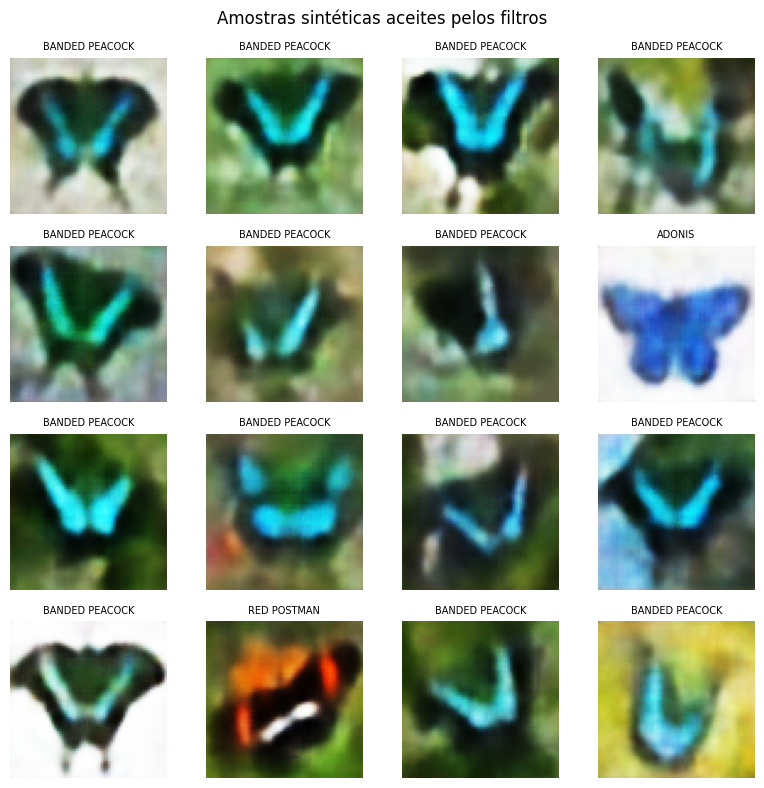

In [24]:
# --- GERAÇÃO DE NOVAS IMAGENS COM FILTRO DE UTILIDADE E DIVERSIDADE ---
required_generation_variables = ['best_generative_model_name', 'model', 'device', 'dataset', 'vae', 'netG']
missing_generation_variables = [name for name in required_generation_variables if name not in globals()]

if missing_generation_variables:
    raise RuntimeError(f'Executa primeiro as células anteriores. Variáveis em falta: {missing_generation_variables}')

set_global_seed(SEED)
model.eval()  # CNN baseline usada para validar ou pseudo-rotular as imagens geradas.
vae.eval()
netG.eval()

generated_images_list = []
generated_labels_list = []
generated_sources_list = []
synthetic_counts_by_class = Counter()


def can_accept_class(label_idx):
    return synthetic_counts_by_class[int(label_idx)] < MAX_SYNTHETIC_PER_CLASS


def accept_generated_image(image_tensor, label_idx, source_name):
    label_idx = int(label_idx)
    if not can_accept_class(label_idx):
        return False

    generated_images_list.append(image_tensor.detach().cpu())
    generated_labels_list.append(torch.tensor(label_idx, dtype=torch.long))
    generated_sources_list.append(source_name)
    synthetic_counts_by_class[label_idx] += 1
    return True


# 1. VAE condicionado: parte de imagens reais, perturba ligeiramente o espaço latente e mantém o rótulo real.
# A imagem só entra no dataset se a CNN concordar com o rótulo real e estiver confiante.
vae_candidates = 0
vae_accepted = 0

with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        mu, logvar = vae.encode(images)
        perturbed_z = mu + VAE_LATENT_NOISE_STD * torch.randn_like(mu)
        fake_images = vae.decode(perturbed_z)

        outputs = model(fake_images)
        probabilities = F.softmax(outputs, dim=1)
        max_probs, preds = torch.max(probabilities, 1)

        for i in range(fake_images.size(0)):
            vae_candidates += 1
            label_idx = int(labels[i].item())
            prediction_matches_label = int(preds[i].item()) == label_idx
            confidence_is_high = float(max_probs[i].item()) >= CONFIDENCE_THRESHOLD

            if prediction_matches_label and confidence_is_high:
                if accept_generated_image(fake_images[i], label_idx, 'VAE condicionado'):
                    vae_accepted += 1

        if all(count >= MAX_SYNTHETIC_PER_CLASS for count in synthetic_counts_by_class.values()) and len(synthetic_counts_by_class) == n_classes:
            break


# 2. DCGAN: gera imagens a partir de ruído. Como não há rótulo real associado,
# usa pseudo-rótulo da CNN, sempre com confiança mínima e limite por classe.
dcgan_candidates = 0
dcgan_accepted = 0

with torch.no_grad():
    for _ in range(NUM_IMAGES_TO_GENERATE // BATCH_Z):
        noise = torch.randn(BATCH_Z, latent_size, 1, 1, device=device)
        fake_images = netG(noise)

        outputs = model(fake_images)
        probabilities = F.softmax(outputs, dim=1)
        max_probs, preds = torch.max(probabilities, 1)

        for i in range(fake_images.size(0)):
            dcgan_candidates += 1
            label_idx = int(preds[i].item())
            confidence_is_high = float(max_probs[i].item()) >= CONFIDENCE_THRESHOLD

            if confidence_is_high:
                if accept_generated_image(fake_images[i], label_idx, 'DCGAN'):
                    dcgan_accepted += 1


generated_images_count = len(generated_images_list)
generated_source_counts = Counter(generated_sources_list)
generated_class_coverage = len(synthetic_counts_by_class)

print('Resumo da geração sintética:')
print(f'Modelo melhor nas métricas generativas globais: {best_generative_model_name}')
print(f'VAE condicionado | Candidatas: {vae_candidates} | Aceites: {vae_accepted}')
print(f'DCGAN | Candidatas: {dcgan_candidates} | Aceites: {dcgan_accepted}')
print(f'Total de imagens sintéticas aceites: {generated_images_count}')
print(f'Cobertura de classes nas imagens sintéticas: {generated_class_coverage}/{n_classes}')
print(f'Limite máximo por classe sintética: {MAX_SYNTHETIC_PER_CLASS}')
print('Imagens aceites por fonte:', dict(generated_source_counts))

if generated_images_count == 0:
    print('Aviso: nenhuma imagem passou os filtros. O dataset aumentado ficará igual ao treino original.')
else:
    generation_summary_df = pd.DataFrame([
        {
            'Fonte': source,
            'Imagens aceites': count
        }
        for source, count in generated_source_counts.items()
    ])
    display(generation_summary_df)

    class_count_preview = pd.DataFrame([
        {
            'Classe': dataset.classes[class_idx],
            'Imagens sintéticas aceites': count
        }
        for class_idx, count in synthetic_counts_by_class.most_common(10)
    ])
    print('Top 10 classes com mais imagens sintéticas aceites:')
    display(class_count_preview)

    preview_count = min(16, generated_images_count)
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        if i < preview_count:
            img = generated_images_list[i].permute(1, 2, 0).numpy()
            label_name = dataset.classes[int(generated_labels_list[i].item())]
            ax.imshow(img)
            ax.set_title(label_name[:18], fontsize=7)
        ax.axis('off')

    plt.suptitle('Amostras sintéticas aceites pelos filtros', fontsize=12)
    plt.tight_layout()
    plt.show()

In [25]:
# --- DIAGNÓSTICO: CONFIANÇA DA CNN NAS IMAGENS GERADAS POR CADA MODELO ---
DIAGNOSTIC_IMAGES = 2000
DIAGNOSTIC_BATCH_SIZE = 100
DIAGNOSTIC_THRESHOLD = CONFIDENCE_THRESHOLD

model.eval()
vae.eval()
netG.eval()


def sample_from_generator(generator_name, batch_size):
    if generator_name == 'VAE':
        vae_latent_dim = vae.fc_mu.out_features
        noise = torch.randn(batch_size, vae_latent_dim, device=device)
        return vae.decode(noise)

    if generator_name == 'DCGAN':
        noise = torch.randn(batch_size, latent_size, 1, 1, device=device)
        return netG(noise)

    raise ValueError(f'Modelo generativo não suportado: {generator_name}')


def evaluate_generator_confidence(generator_name):
    all_max_probs = []
    accepted_preds = []

    with torch.no_grad():
        for _ in range(DIAGNOSTIC_IMAGES // DIAGNOSTIC_BATCH_SIZE):
            generated_batch = sample_from_generator(generator_name, DIAGNOSTIC_BATCH_SIZE)
            outputs = model(generated_batch)
            probabilities = F.softmax(outputs, dim=1)
            max_probs, preds = torch.max(probabilities, 1)

            all_max_probs.extend(max_probs.cpu().tolist())
            accepted_preds.extend(preds[max_probs >= DIAGNOSTIC_THRESHOLD].cpu().tolist())

    accepted_count = len(accepted_preds)
    class_coverage = len(set(accepted_preds)) if accepted_count > 0 else 0

    return {
        'Modelo generativo': generator_name,
        'Candidatas avaliadas': len(all_max_probs),
        'Confiança média da CNN': sum(all_max_probs) / len(all_max_probs),
        'Confiança máxima da CNN': max(all_max_probs),
        f'Aceites >= {DIAGNOSTIC_THRESHOLD}': accepted_count,
        'Cobertura de classes aceites': class_coverage
    }

confidence_diagnostic_df = pd.DataFrame([
    evaluate_generator_confidence('VAE'),
    evaluate_generator_confidence('DCGAN')
])

display(confidence_diagnostic_df)

,Modelo generativo,Candidatas avaliadas,Confiança média da CNN,Confiança máxima da CNN,Aceites >= 0.85,Cobertura de classes aceites
0,VAE,2000,0.585033,0.71101,0,0
1,DCGAN,2000,0.697276,1.00000,820,3


In [26]:
# --- DIAGNÓSTICO: VAE COMO AUMENTO CONDICIONADO POR IMAGENS REAIS ---
VAE_DIAGNOSTIC_IMAGES = 1000
VAE_LATENT_NOISE_STD = 0.15

vae.eval()
model.eval()

vae_augmented_candidates = 0
vae_reconstruction_agreement = 0
vae_reconstruction_confident = 0
vae_perturbed_agreement = 0
vae_perturbed_confident = 0

with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        mu, logvar = vae.encode(images)

        reconstructions = vae.decode(mu)
        perturbed_z = mu + VAE_LATENT_NOISE_STD * torch.randn_like(mu)
        perturbed_images = vae.decode(perturbed_z)

        for generated_batch, mode_name in [
            (reconstructions, 'reconstruction'),
            (perturbed_images, 'perturbed')
        ]:
            outputs = model(generated_batch)
            probabilities = F.softmax(outputs, dim=1)
            max_probs, preds = torch.max(probabilities, 1)
            agreement = preds == labels
            confident = max_probs >= CONFIDENCE_THRESHOLD

            if mode_name == 'reconstruction':
                vae_reconstruction_agreement += int(agreement.sum().item())
                vae_reconstruction_confident += int((agreement & confident).sum().item())
            else:
                vae_perturbed_agreement += int(agreement.sum().item())
                vae_perturbed_confident += int((agreement & confident).sum().item())

        vae_augmented_candidates += images.size(0)
        if vae_augmented_candidates >= VAE_DIAGNOSTIC_IMAGES:
            break

vae_augmented_candidates = min(vae_augmented_candidates, VAE_DIAGNOSTIC_IMAGES)

vae_conditioned_diagnostic_df = pd.DataFrame([
    {
        'Modo VAE': 'Reconstrução com z=mu',
        'Candidatas avaliadas': vae_augmented_candidates,
        'Concordância com rótulo real': vae_reconstruction_agreement,
        f'Concordância e confiança >= {CONFIDENCE_THRESHOLD}': vae_reconstruction_confident
    },
    {
        'Modo VAE': f'Perturbação latente std={VAE_LATENT_NOISE_STD}',
        'Candidatas avaliadas': vae_augmented_candidates,
        'Concordância com rótulo real': vae_perturbed_agreement,
        f'Concordância e confiança >= {CONFIDENCE_THRESHOLD}': vae_perturbed_confident
    }
])

display(vae_conditioned_diagnostic_df)

,Modo VAE,Candidatas avaliadas,Concordância com rótulo real,Concordância e confiança >= 0.85
0,Reconstrução com z=mu,1000,60,7
1,Perturbação latente std=0.15,1000,61,7


N.9 - Criação do Dataset Aumentado

In [27]:
# Definir um Dataset simples para as imagens geradas na memória
class GeneratedDataset(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

# Criar a instância do dataset gerado
gen_dataset = GeneratedDataset(generated_images_list, generated_labels_list)

# JUNTAR TUDO: Dados reais + Dados gerados sinteticamente
augmented_train_dataset = ConcatDataset([train_dataset, gen_dataset])

# Criar o novo DataLoader
augmented_train_loader = DataLoader(
    augmented_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED)
)

print(f"Tamanho do Dataset Original: {len(train_dataset)}")
print(f"Imagens Sintéticas Aceites: {len(gen_dataset)}")
print(f"Tamanho do Dataset Aumentado: {len(augmented_train_dataset)}")

Tamanho do Dataset Original: 3639
Imagens Sintéticas Aceites: 120
Tamanho do Dataset Aumentado: 3759


N.10 - Re-treino da Baseline CNN

In [28]:
# 1. Criar a instância da rede DO ZERO.
# A seed é reposta para aproximar a comparação: muda o dataset, não a inicialização.
set_global_seed(SEED)
augmented_model = BaselineCNN(num_classes=n_classes).to(device)

# 2. Usar o otimizador e a loss OBRIGATÓRIOS
optimizer_aug = optim.Adam(augmented_model.parameters(), lr=0.001)
criterion_aug = nn.CrossEntropyLoss()

# Hiperparâmetros iguais à Fase 1
best_val_loss_aug = float('inf')
patience_counter_aug = 0
best_aug_weights = copy.deepcopy(augmented_model.state_dict())

print("\n--- A iniciar o re-treino com o Augmented Dataset ---")
print(f"Amostras reais: {len(train_dataset)} | Amostras sintéticas: {len(gen_dataset)}")

for epoch in range(EPOCHS): # Usa a mesma variável EPOCHS da Fase 1
    # --- FASE DE TREINO ---
    augmented_model.train()
    train_loss = 0.0

    for images, labels in augmented_train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer_aug.zero_grad()
        outputs = augmented_model(images)
        loss = criterion_aug(outputs, labels)
        loss.backward()
        optimizer_aug.step()

        train_loss += loss.item() * images.size(0)

    train_loss /= len(augmented_train_loader.dataset)

    # --- FASE DE VALIDAÇÃO ---
    # Nota: Usamos exatamente o mesmo val_loader de imagens reais da Fase 1 para garantir uma comparação justa.
    augmented_model.eval()
    val_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = augmented_model(images)
            loss = criterion_aug(outputs, labels)
            val_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss /= len(val_loader.dataset)
    val_accuracy = accuracy_score(all_labels, all_preds)
    val_f1 = f1_score(all_labels, all_preds, average='weighted')

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.4f} | Val F1: {val_f1:.4f}")

    # --- EARLY STOPPING ---
    if val_loss < best_val_loss_aug:
        best_val_loss_aug = val_loss
        patience_counter_aug = 0
        best_aug_weights = copy.deepcopy(augmented_model.state_dict())
    else:
        patience_counter_aug += 1
        if patience_counter_aug >= PATIENCE:
            print(f"Early stopping ativado na época {epoch+1}!")
            break

# Carregar os melhores pesos e avaliar no Test Loader
augmented_model.load_state_dict(best_aug_weights)
augmented_model.eval()

test_preds = []
test_labels_list = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = augmented_model(images)
        _, preds = torch.max(outputs, 1)
        test_preds.extend(preds.cpu().numpy())
        test_labels_list.extend(labels.cpu().numpy())

test_accuracy_aug = accuracy_score(test_labels_list, test_preds)
test_f1_aug = f1_score(test_labels_list, test_preds, average='weighted')

print("\n--- COMPARAÇÃO FINAL (Conjunto de Teste) ---")
print(f"Baseline Original - Test Accuracy: {test_accuracy:.4f} | Test F1: {test_f1:.4f}")
print(f"Baseline Aumentada - Test Accuracy: {test_accuracy_aug:.4f} | Test F1: {test_f1_aug:.4f}")


--- A iniciar o re-treino com o Augmented Dataset ---
Amostras reais: 3639 | Amostras sintéticas: 120
Epoch 01/50 | Train Loss: 4.1226 | Val Loss: 4.2551 | Val Acc: 0.0282 | Val F1: 0.0049
Epoch 02/50 | Train Loss: 3.8865 | Val Loss: 4.2149 | Val Acc: 0.0192 | Val F1: 0.0025
Epoch 03/50 | Train Loss: 3.6450 | Val Loss: 3.5795 | Val Acc: 0.0846 | Val F1: 0.0480
Epoch 04/50 | Train Loss: 3.5133 | Val Loss: 3.3714 | Val Acc: 0.0987 | Val F1: 0.0478
Epoch 05/50 | Train Loss: 3.4059 | Val Loss: 3.3716 | Val Acc: 0.1192 | Val F1: 0.0767
Epoch 06/50 | Train Loss: 3.3038 | Val Loss: 3.4515 | Val Acc: 0.1077 | Val F1: 0.0669
Epoch 07/50 | Train Loss: 3.2324 | Val Loss: 3.1439 | Val Acc: 0.1679 | Val F1: 0.1226
Epoch 08/50 | Train Loss: 3.1110 | Val Loss: 2.9852 | Val Acc: 0.1744 | Val F1: 0.1271
Epoch 09/50 | Train Loss: 3.0216 | Val Loss: 3.1276 | Val Acc: 0.1397 | Val F1: 0.0921
Epoch 10/50 | Train Loss: 2.9783 | Val Loss: 3.0420 | Val Acc: 0.1718 | Val F1: 0.1360
Epoch 11/50 | Train Loss: 2

N.11 - Visualização dos Resultados para o Relatório (Avaliação Comparativa)

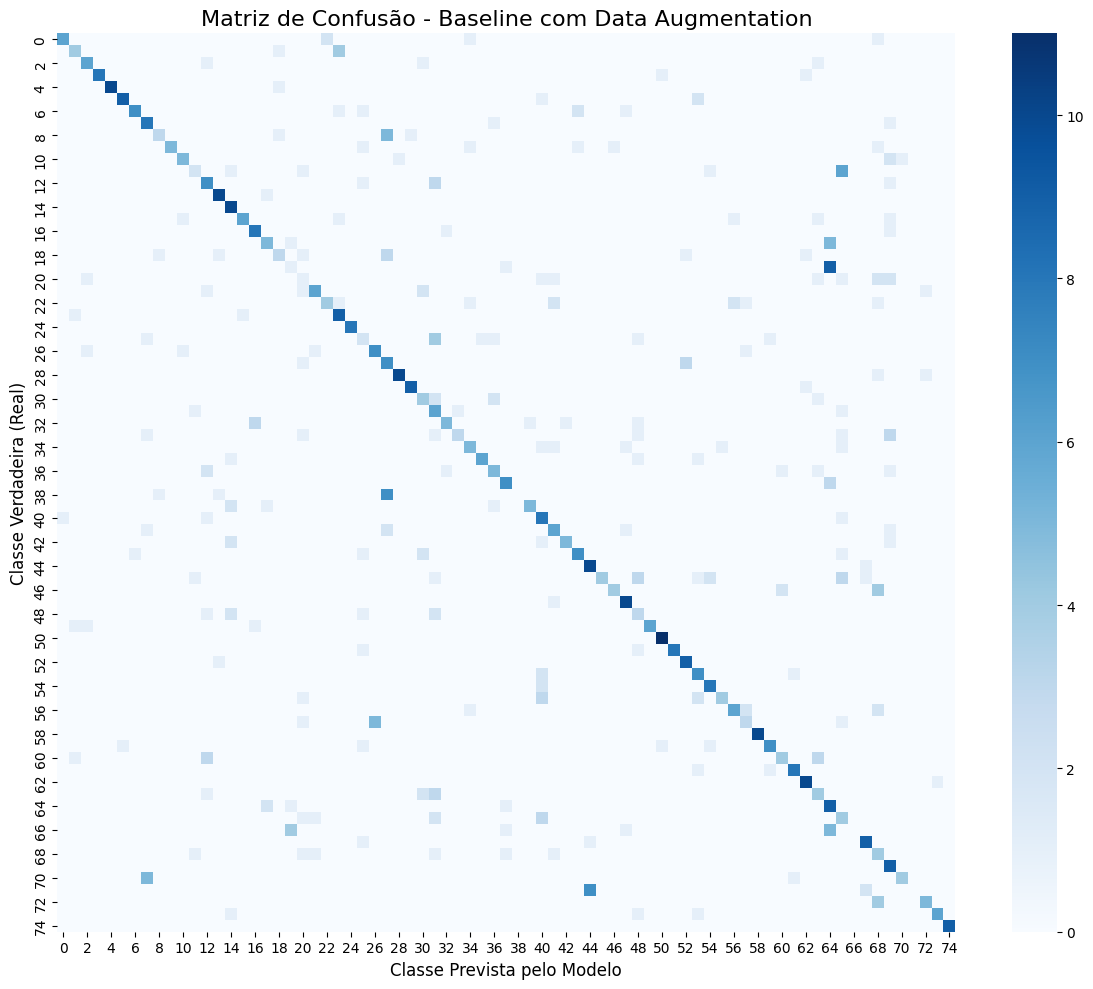

In [29]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Usamos as variáveis test_labels_list e test_preds da Fase 3
cm = confusion_matrix(test_labels_list, test_preds)

plt.figure(figsize=(12, 10))
# annot=False porque imprimir 75x75 números ia tornar o gráfico ilegível
sns.heatmap(cm, annot=False, cmap='Blues', cbar=True)
plt.title('Matriz de Confusão - Baseline com Data Augmentation', fontsize=16)
plt.ylabel('Classe Verdadeira (Real)', fontsize=12)
plt.xlabel('Classe Prevista pelo Modelo', fontsize=12)
plt.tight_layout()
plt.show()


In [30]:
from pathlib import Path
import torch

# Guardar modelos numa pasta explícita junto da pasta aca-butterflies.
# Se o dataset estiver no Google Drive, os ficheiros ficam também no Drive.
project_output_dir = Path(path).resolve().parent
model_output_dir = project_output_dir / 'models'
model_output_dir.mkdir(parents=True, exist_ok=True)

model_paths = {
    'baseline_cnn': model_output_dir / 'baseline_cnn.pth',
    'vae_model': model_output_dir / 'vae_model.pth',
    'gan_generator': model_output_dir / 'gan_generator.pth',
    'augmented_model': model_output_dir / 'augmented_model.pth'
}

# Fase 1: Guardar a Baseline CNN original
torch.save(model.state_dict(), model_paths['baseline_cnn'])

# Fase 2: Guardar o VAE e o Gerador da GAN
torch.save(vae.state_dict(), model_paths['vae_model'])
torch.save(netG.state_dict(), model_paths['gan_generator'])

# Fase 3: Guardar a Baseline treinada com dados aumentados
torch.save(augmented_model.state_dict(), model_paths['augmented_model'])

print('Todos os modelos foram guardados com sucesso em:')
for model_name, model_path in model_paths.items():
    print(f'{model_name}: {model_path}')

Todos os modelos foram guardados com sucesso em:
baseline_cnn: /content/drive/MyDrive/content/ACA/models/baseline_cnn.pth
vae_model: /content/drive/MyDrive/content/ACA/models/vae_model.pth
gan_generator: /content/drive/MyDrive/content/ACA/models/gan_generator.pth
augmented_model: /content/drive/MyDrive/content/ACA/models/augmented_model.pth


N.12 - Geração do Ficheiro para a Competição Kaggle

In [31]:
import glob
import os
import pandas as pd
import torch

# --- 1. PREPARAÇÃO DO DATASET DE TESTE (KAGGLE) ---
class KaggleTestDataset(torch.utils.data.Dataset):
    def __init__(self, test_dir, transform=None):
        self.image_paths = sorted(glob.glob(os.path.join(test_dir, '*.jpg')))
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        img_id = os.path.basename(img_path)

        if self.transform:
            image = self.transform(image)

        return image, img_id

# Como path aponta para a pasta aca-butterflies, a pasta de teste fica diretamente dentro dela.
test_dir = os.path.join(path, 'test')

kaggle_test_dataset = KaggleTestDataset(test_dir=test_dir, transform=data_transform)
kaggle_test_loader = torch.utils.data.DataLoader(
    kaggle_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"Foram encontradas {len(kaggle_test_dataset)} imagens para a submissão do Kaggle.")

# --- 2. ESCOLHER O MELHOR CLASSIFICADOR INTERNO ---
required_submission_variables = ['model', 'augmented_model', 'test_f1', 'test_f1_aug', 'test_accuracy', 'test_accuracy_aug']
missing_submission_variables = [name for name in required_submission_variables if name not in globals()]

if missing_submission_variables:
    raise RuntimeError(f'Executa primeiro as células de treino e avaliação. Variáveis em falta: {missing_submission_variables}')

if (test_f1_aug > test_f1) or (test_f1_aug == test_f1 and test_accuracy_aug >= test_accuracy):
    submission_model = augmented_model
    submission_model_name = 'Baseline com dataset aumentado'
    submission_accuracy = test_accuracy_aug
    submission_f1 = test_f1_aug
else:
    submission_model = model
    submission_model_name = 'Baseline original'
    submission_accuracy = test_accuracy
    submission_f1 = test_f1

submission_model.eval()

print(f"Modelo usado na submissão: {submission_model_name}")
print(f"Métricas internas do modelo usado | Test Accuracy: {submission_accuracy:.4f} | Test F1: {submission_f1:.4f}")

idx_to_class = {idx: class_name for idx, class_name in enumerate(dataset.classes)}
submission_rows = []

with torch.no_grad():
    for images, image_ids in kaggle_test_loader:
        images = images.to(device)
        outputs = submission_model(images)
        _, preds = torch.max(outputs, 1)

        for image_id, pred_idx in zip(image_ids, preds.cpu().numpy()):
            submission_rows.append({
                'filename': image_id,
                'label': idx_to_class[int(pred_idx)]
            })

submission_df = pd.DataFrame(submission_rows, columns=['filename', 'label'])

# --- 3. GUARDAR CSV DE SUBMISSÃO ---
drive_output_dir = '/content/drive/MyDrive/content/ACA'
if os.path.isdir(drive_output_dir):
    submission_path = os.path.join(drive_output_dir, 'submission.csv')
else:
    submission_path = 'submission.csv'

submission_df.to_csv(submission_path, index=False)
print('Guardado em:', submission_path)

print("Ficheiro submission.csv criado com sucesso!")
display(submission_df.head())

Foram encontradas 1300 imagens para a submissão do Kaggle.
Modelo usado na submissão: Baseline original
Métricas internas do modelo usado | Test Accuracy: 0.6167 | Test F1: 0.6135
Guardado em: /content/drive/MyDrive/content/ACA/submission.csv
Ficheiro submission.csv criado com sucesso!


,filename,label
0,Image_0.jpg,RED ADMIRAL
1,Image_1.jpg,APPOLLO
2,Image_10.jpg,PIPEVINE SWALLOW
3,Image_100.jpg,POPINJAY
4,Image_1000.jpg,MALACHITE
